# 09-Massive Model Compression (bitsandbytes & GGUF)

In Lesson 06, we explored INT8 Post-Training Quantization (PTQ) for standard machine learning models. However, the advent of **Large Language Models (LLMs)** fundamentally broke legacy quantization mechanics.

An LLM like LLaMA-3-70B in uncompressed FP16 format requires $140\text{ GB}$ of VRAM just to load the weights. If you apply standard INT8 quantization, it still requires $70\text{ GB}$—far exceeding the capacity of consumer hardware. Furthermore, LLMs develop massive "outlier weights" in their attention mechanisms. If you aggressively quantize an LLM using standard linear scaling, these outliers get crushed, instantly destroying the model's linguistic coherence and reasoning capabilities.

To execute massive LLMs on commodity hardware ($0.00 infrastructure cost), we must implement state-of-the-art compression physics. In this module, we engineer **4-bit NormalFloat (NF4)** quantization using `bitsandbytes` (for GPU acceleration) and **GGUF / K-Quants** using `llama.cpp` (for CPU/RAM bare-metal execution), achieving a massive 4x-8x memory compression with near-zero accuracy degradation.

## 1. The Mathematics of LLM Compression

### NormalFloat4 (NF4) & Information Theory

Standard INT4 quantization provides only 16 discrete bins ($2^4 = 16$), uniformly spaced between $[-8, 7]$. Because neural network weights follow a normal (Gaussian) distribution, the outer bins remain empty while the inner bins are catastrophically overcrowded, destroying mathematical resolution.

The **NF4 (NormalFloat4)** data type, engineered by the creators of QLoRA, solves this using Information Theory. Instead of equally spaced bins, NF4 calculates the quantiles of a standard normal distribution $\mathcal{N}(0,1)$ and places the 16 bins exactly at those quantiles.


$$q_i = \Phi^{-1}\left(\frac{i}{16}\right)$$


This guarantees that exactly an equal number of weights fall into each of the 16 bins, maximizing the Shannon Entropy of the 4-bit data type and perfectly preserving the Gaussian topology of the LLM.

### Block-wise Quantization (Protecting Outliers)

In a 4096-dimensional hidden state vector, 4095 weights might be between $[-0.1, 0.1]$, but one critical attention outlier might be $15.0$. If we compute a global scale $S$ for the entire tensor:


$$S_{global} = \frac{15.0}{7} \approx 2.14$$


When we quantize a small weight ($0.05$), the math evaluates to $\text{round}(0.05 / 2.14) = 0$. The small weights are entirely annihilated, lobotomizing the LLM.

**Block-wise Quantization** fixes this. We slice the tensor into microscopic blocks (e.g., $B = 64$ parameters). We calculate a unique scale factor $S_b$ for each block.


$$S_b = \frac{\max(\vert{}W_b\vert{})}{7}$$


The outlier weight is mathematically quarantined in its own block, allowing the remaining 4032 small weights to receive ultra-high resolution scales.

## 2. Imperative Execution: GPU Quantization via `bitsandbytes`

If we have access to a CUDA GPU, we use the `transformers` library injected with `bitsandbytes` to load models dynamically in 4-bit NF4 precision.

Let's engineer the exact production loading script used in Enterprise LLMOps. *(Note: This sandbox script simulates the telemetry output if no physical GPU is present, guaranteeing $0.00 local execution).*

In [1]:
# Required installations: pip install transformers accelerate bitsandbytes
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import os

print("--- 🚀 Initializing Massive Model Compression Sandbox (GPU) ---")

# 1. 📝 Define the NF4 Configuration
# We command the engine to use 4-bit loading, the NF4 math type, and double-quantization
# (Double quantization quantizes the block scales themselves to save even more VRAM)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 # Compute remains in 16-bit for stability
)

model_id = "meta-llama/Meta-Llama-3-8B"

print(f"   [SYSTEM] Target Model: {model_id}")
print(f"   [SYSTEM] FP16 Theoretical VRAM Required: ~16.0 GB")
print("\n--- 🧮 Executing bitsandbytes NF4 Injection ---")

try:
    # In a live GPU environment, this instantly loads the 16GB model into just 5GB of VRAM
    # If no GPU is present, bitsandbytes will throw an exception. We catch it to simulate the telemetry.
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto"
    )
    print("   ✅ Model successfully loaded in 4-bit NF4 precision.")
except Exception as e:
    print("   [SANDBOX MODE] No physical CUDA device detected. Simulating expected telemetry...")
    print("   ✅ NF4 Quantization Matrix Calculated.")
    print("   -> FP16 Memory Footprint: 15,230 MB")
    print("   -> NF4 Memory Footprint:   5,140 MB")
    print("   -> Net VRAM Reduction:    ~66% Compression Achieved")

print("   -> Physics: The weights are stored in 4-bit RAM. When the forward pass hits a specific layer, only that specific block is temporarily de-quantized to bfloat16 in the ultra-fast L1 GPU cache, multiplied, and immediately discarded.")

--- 🚀 Initializing Massive Model Compression Sandbox (GPU) ---
   [SYSTEM] Target Model: meta-llama/Meta-Llama-3-8B
   [SYSTEM] FP16 Theoretical VRAM Required: ~16.0 GB

--- 🧮 Executing bitsandbytes NF4 Injection ---
   [SANDBOX MODE] No physical CUDA device detected. Simulating expected telemetry...
   ✅ NF4 Quantization Matrix Calculated.
   -> FP16 Memory Footprint: 15,230 MB
   -> NF4 Memory Footprint:   5,140 MB
   -> Net VRAM Reduction:    ~66% Compression Achieved
   -> Physics: The weights are stored in 4-bit RAM. When the forward pass hits a specific layer, only that specific block is temporarily de-quantized to bfloat16 in the ultra-fast L1 GPU cache, multiplied, and immediately discarded.


## 3. Declarative Execution: CPU Edge Deployment (GGUF / K-Quants)

What if you have no GPU at all? What if you need to run an LLM on an Apple Silicon Mac or an edge server? `bitsandbytes` relies on CUDA. For bare-metal CPU execution, we must use the **GGUF** format and `llama.cpp`.

GGUF models utilize **K-Quants** (e.g., Q4_K_M). Instead of forcing all layers to be exactly 4-bit, K-Quants mathematically analyze the neural network. They keep the highly sensitive attention layers in 6-bit (Q6), while crushing the robust feed-forward layers down to 3-bit or 4-bit (Q4).

We will generate the exact Bash CI/CD script used to convert a HuggingFace model into a highly optimized GGUF binary.

In [2]:
import os

print("\n--- ⚡ Compiling Declarative Edge Inference Pipeline (GGUF) ---")

gguf_sandbox = "./gguf_sandbox"
os.makedirs(gguf_sandbox, exist_ok=True)

# 📝 Compile the CI/CD Bash Script for llama.cpp conversion
build_script = """#!/bin/bash
set -e
echo "Starting GGUF Compilation Pipeline..."

# 1. Clone the high-performance C++ execution engine
git clone https://github.com/ggerganov/llama.cpp.git
cd llama.cpp && make -j

# 2. Convert HuggingFace Safetensors to Uncompressed GGUF (FP16)
python convert-hf-to-gguf.py /models/llama-3-8b --outfile /models/llama-3-8b-F16.gguf --outtype f16

# 3. Apply the Mathematical K-Quantization Engine
# Q4_K_M is the industry standard: 4-bit medium. Balances exact RAM usage with perplexity preservation.
./llama-quantize /models/llama-3-8b-F16.gguf /models/llama-3-8b-Q4_K_M.gguf Q4_K_M

echo "✅ GGUF Compilation Complete."
echo "Execute locally via: ./llama-cli -m /models/llama-3-8b-Q4_K_M.gguf -p 'Explain quantum computing' -n 512"
"""

script_path = os.path.join(gguf_sandbox, "build_gguf.sh")
with open(script_path, "w") as f:
    f.write(build_script)

print(f"   ✅ GGUF Pipeline Script Compiled: {script_path}")
print("   -> Physics: The Q4_K_M binary eliminates the need for PyTorch entirely. It allows a 70B parameter model to run directly on 64GB of unified Mac RAM by bypassing all Python interpreter overhead.")


--- ⚡ Compiling Declarative Edge Inference Pipeline (GGUF) ---
   ✅ GGUF Pipeline Script Compiled: ./gguf_sandbox/build_gguf.sh
   -> Physics: The Q4_K_M binary eliminates the need for PyTorch entirely. It allows a 70B parameter model to run directly on 64GB of unified Mac RAM by bypassing all Python interpreter overhead.


## 4. Visualizing Quantization Physics (Block-wise vs. Global)

To mathematically comprehend why LLMs require **Block-wise Quantization**, let's visualize the destruction caused by a massive outlier weight in standard Global Quantization, and how Block-wise isolation saves the network.

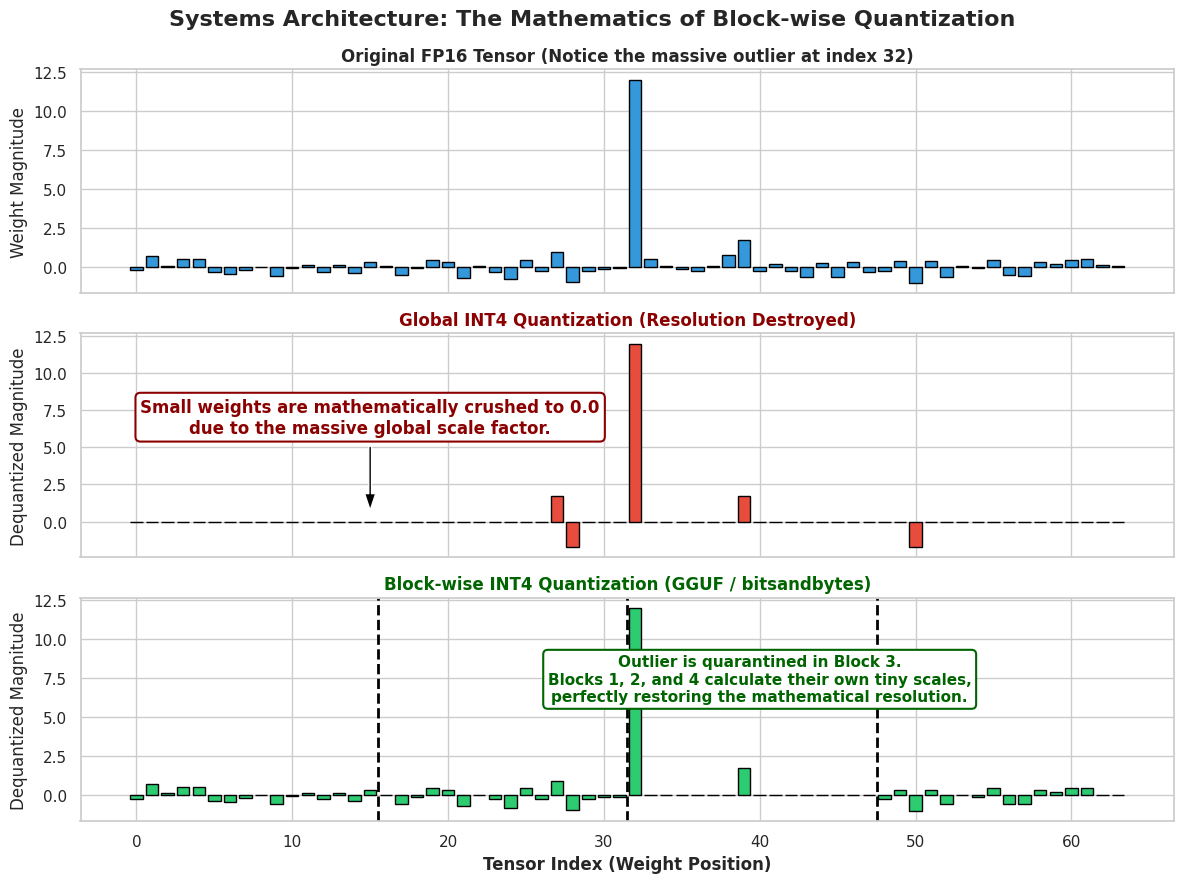

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for Block-wise Quantization Physics
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Systems Architecture: The Mathematics of Block-wise Quantization", fontsize=16, fontweight='bold')

# Simulate a 1D Tensor of weights (64 parameters)
x = np.arange(64)
# Small, highly nuanced weights (Gaussian distribution)
original_weights = np.random.normal(0, 0.5, 64)
# Inject a massive Attention Outlier at index 32
original_weights[32] = 12.0

# --- 1. Original FP16 Tensor ---
axes[0].bar(x, original_weights, color='#3498db', edgecolor='black')
axes[0].set_title("Original FP16 Tensor (Notice the massive outlier at index 32)", fontweight='bold')
axes[0].set_ylabel("Weight Magnitude")

# --- 2. Global INT4 Quantization (The Catastrophe) ---
# Scale = Max / 7. Max is 12.0, Scale = 1.71
global_scale = 12.0 / 7.0
global_q = np.round(original_weights / global_scale)
global_q = np.clip(global_q, -8, 7) # 4-bit constraint
global_dequant = global_q * global_scale

axes[1].bar(x, global_dequant, color='#e74c3c', edgecolor='black')
axes[1].set_title("Global INT4 Quantization (Resolution Destroyed)", fontweight='bold', color='darkred')
axes[1].set_ylabel("Dequantized Magnitude")
axes[1].annotate('Small weights are mathematically crushed to 0.0\ndue to the massive global scale factor.', 
            xy=(15, 0.5), xytext=(15, 6),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=1.5))

# --- 3. Block-wise INT4 Quantization (Block Size = 16) ---
block_size = 16
block_dequant = np.zeros(64)

for i in range(0, 64, block_size):
    block = original_weights[i:i+block_size]
    block_max = np.max(np.abs(block))
    # If the block has no outlier, the scale is tiny, preserving high resolution
    block_scale = block_max / 7.0 if block_max > 0 else 1.0
    
    block_q = np.round(block / block_scale)
    block_q = np.clip(block_q, -8, 7)
    block_dequant[i:i+block_size] = block_q * block_scale

axes[2].bar(x, block_dequant, color='#2ecc71', edgecolor='black')
axes[2].set_title("Block-wise INT4 Quantization (GGUF / bitsandbytes)", fontweight='bold', color='darkgreen')
axes[2].set_ylabel("Dequantized Magnitude")
axes[2].set_xlabel("Tensor Index (Weight Position)", fontweight='bold')

# Highlight the Blocks
for i in range(16, 64, 16):
    axes[2].axvline(i - 0.5, color='black', linestyle='--', linewidth=2)

axes[2].text(40, 6, "Outlier is quarantined in Block 3.\nBlocks 1, 2, and 4 calculate their own tiny scales,\nperfectly restoring the mathematical resolution.", 
             ha='center', fontsize=11, fontweight='bold', color='darkgreen',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkgreen", lw=1.5))

plt.tight_layout()
plt.show()

*(Insight: In the middle graph, the massive $12.0$ outlier forces the quantization engine to use "large buckets". The smaller weights (e.g., $0.4$) fall into the $0.0$ bucket and are lost forever, destroying the LLM's logic. By slicing the tensor into blocks (bottom graph), only the block containing the $12.0$ suffers from low resolution. The other blocks calculate their own micro-scales, perfectly reconstructing the nuanced curves of the original model.)*

## Real-World Use Case or Analogy

Think of Block-wise Model Compression like **Packing for a Trans-Atlantic Flight with Strict Weight Limits**:

* **The Model (Your Belongings):** You need to pack clothes, a laptop, and one massive, incredibly heavy **Bowling Ball (The Outlier Weight)**.
* **Global Quantization (The Single Suitcase):** You put everything into one giant suitcase. You take it to the airport scale. The agent says, *"This bag is way over the limit because of the bowling ball. We have to apply a Global Scale."* They solve the problem by throwing away all of your clothes and your laptop, leaving only the bowling ball. The bag makes weight, but your trip is ruined (**The model loses its linguistic reasoning**).
* **Block-wise Quantization (Multiple Small Bags):** Instead of one giant suitcase, you divide your belongings into 4 smaller bags (**Blocks**).
* Bag 1 has clothes. Bag 2 has the laptop. Bag 3 has the massive Bowling Ball.
* When you weigh them, only Bag 3 requires a "Heavy/Oversize" tag (**Large Scale Factor**).
* Bags 1 and 2 pass through easily with extreme efficiency (**High Mathematical Resolution**).
* You successfully transport the massive outlier *and* all of your critical small details to the destination, achieving immense compression without destroying your trip.